In [1]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [2]:
# We want only two columns from dataset i.e. Annual Income (k$) & Spending Score (1-100)
# so we can get it by diifernt ways
# 1.By using iloc[]
# 2.By droping unnecessary columns from dataset
#.....

X = df.iloc[:,[3,4]].values
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

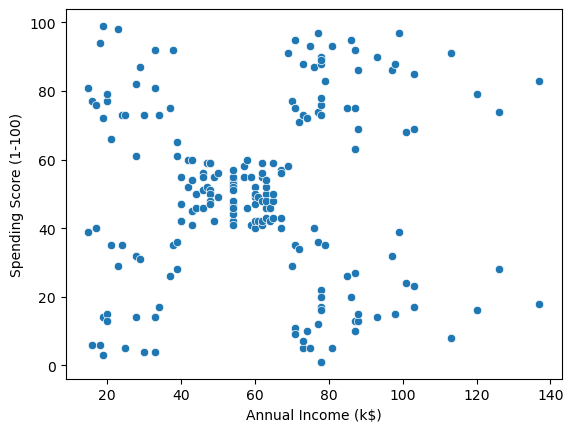

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="Annual Income (k$)",y="Spending Score (1-100)",data=df)
plt.show()

In [4]:
from sklearn.cluster import KMeans


# just applying one cluster
# base model

kmeans_1 = KMeans(n_clusters=1,max_iter=300,random_state=1234)
kmeans_1

KMeans(n_clusters=1, random_state=1234)

In [5]:
X = df.iloc[:,[3,4]]

kmeans_1.fit(X)

KMeans(n_clusters=1, random_state=1234)

In [6]:
kmeans_1.inertia_

269981.28

In [7]:
means = kmeans_1.cluster_centers_
means

array([[60.56, 50.2 ]])

In [8]:
wcss = []

for k in range(1,11):    
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters =k , init = "k-means++")
    kmeans.fit(X)
    kmeans.inertia_        # Here inertia means wcss value for a individual k value.
    wcss.append(kmeans.inertia_)

print(wcss)

[269981.28, 181363.59595959596, 106348.37306211119, 73679.78903948834, 44448.45544793371, 37233.81451071001, 30259.65720728547, 25043.89004329005, 21797.084944646376, 20764.61117003152]


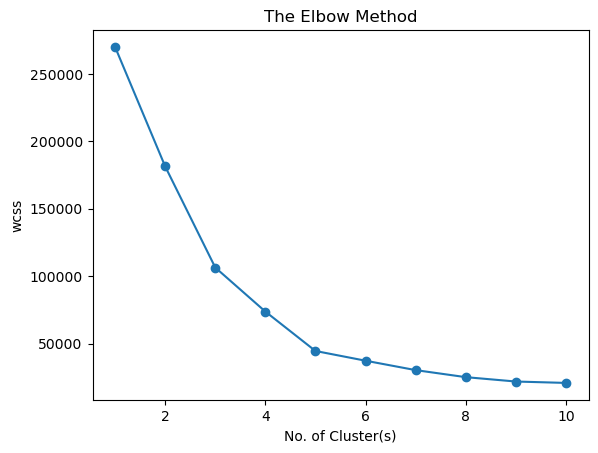

In [9]:
plt.scatter(range(1,11),wcss)
plt.plot(range(1,11),wcss)
plt.title("The Elbow Method")
plt.xlabel("No. of Cluster(s)")
plt.ylabel("wcss")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=5,max_iter=300,random_state=1234)
y_clusters = kmeans.fit_predict(X)
y_clusters


# In Output 
# 0 means cluster_1
# 1 means cluster_2 ....
# 4 means cluster_5.



array([0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 4,
       0, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 3, 1, 4, 1, 3, 1, 3, 1,
       4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1])

In [11]:
df["Cluster_group"]=y_clusters   # It will add one more column in dataset with 'Cluster_group' name which show that the related row data point in which cluster

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,0
1,2,Male,21,15,81,2
2,3,Female,20,16,6,0
3,4,Female,23,16,77,2
4,5,Female,31,17,40,0


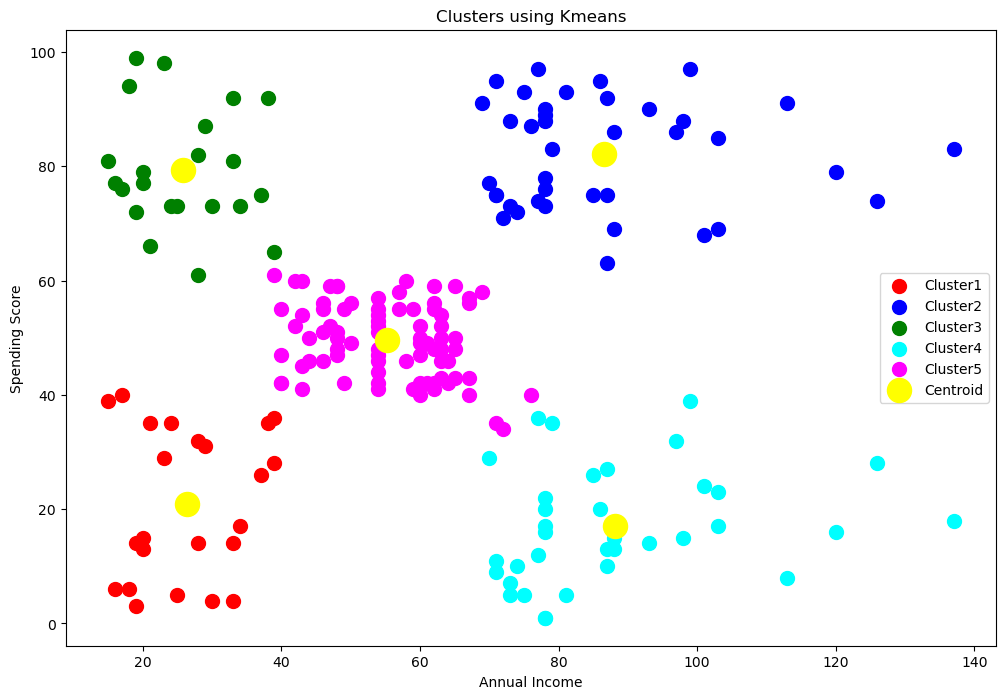

In [12]:
# We are applying scatterplot between 'income' column & 'spending' column with respect to clusters

X=df.iloc[:,[3,4]].values

plt.figure(figsize=(12,8))
plt.scatter(X[y_clusters==0,0],X[y_clusters==0,1],s=100,c='red',label="Cluster1")
plt.scatter(X[y_clusters==1,0],X[y_clusters==1,1],s=100,c='blue',label="Cluster2")
plt.scatter(X[y_clusters==2,0],X[y_clusters==2,1],s=100,c='green',label="Cluster3")
plt.scatter(X[y_clusters==3,0],X[y_clusters==3,1],s=100,c='cyan',label="Cluster4")
plt.scatter(X[y_clusters==4,0],X[y_clusters==4,1],s=100,c='magenta',label="Cluster5")

plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=300,c='yellow',label="Centroid")
plt.title("Clusters using Kmeans")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

In [13]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Mall_Customers.csv")

X = df[['Annual Income (k$)','Spending Score (1-100)']].values

kmeans = KMeans(n_clusters=5)
kmeans.fit(X)
kmeans.labels_
silhouette_score(X,kmeans.labels_)



0.553931997444648

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Mall_Customers.csv")

X = df[['Annual Income (k$)','Spending Score (1-100)']].values

silhouette_scores = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(X,cluster_labels)
    silhouette_scores.append(silhouette_avg)
    
#Find the optimal k value that maximizes silhouette_score
print(silhouette_scores)
k_values=range(2,11)
optimal_k = k_values[np.argmax(silhouette_scores)]   # It will gives the max k_values from silhouette_scores list i.e. k_values[3]= 5
optimal_silhouette_score = max(silhouette_scores)


print("Optimal number of clusters:",optimal_k)
print("optimaal silhouette_score:",optimal_silhouette_score)

[0.2968969162503008, 0.46761358158775435, 0.4931963109249047, 0.553931997444648, 0.5376203956398481, 0.5288104473798049, 0.4581763522413715, 0.46148389463592215, 0.4494755585987857]
Optimal number of clusters: 5
optimaal silhouette_score: 0.553931997444648
